# Exemple de filtre simple

Réponse impulsionnelle, gain, phase, retard de groupe.

In [1]:
import numpy as np
import numpy.fft as fft
import matplotlib.pyplot as plt
import scipy.signal as signal
plt.style.use('../../src/signal.mplstyle')

figure_size = (6,4.5)
xlim = (0,12)

## Simulation

In [2]:
# Abscisses
fe = 100
N = 800
n = np.arange(N)
t = n/fe

# Fenêtre et signaux d'entrée
w = np.concatenate([np.zeros(100), np.hamming(300), np.zeros(N-400)])
f1, f2, f3 = 2, 4, 6
x1 = w * np.sin(2*np.pi*f1*t)
x2 = w * np.sin(2*np.pi*f2*t)
x3 = w * np.sin(2*np.pi*f3*t)

# Filtre
b, a = signal.iirdesign(wp=4, ws=4.5, gpass=1, gstop=30, analog=False,
                        ftype='ellip', output='ba', fs=fe)

# Réponse fréquentielle
w, h = signal.freqz(b, a, worN=N, plot=None, fs=fe)
    
# Retard de groupe
w, gd = signal.group_delay((b,a), w=N, whole=False, fs=fe)

# Signaux de sortie
y1 = signal.lfilter(b,a,x1)
y2 = signal.lfilter(b,a,x2)
y3 = signal.lfilter(b,a,x3)

# Affichage

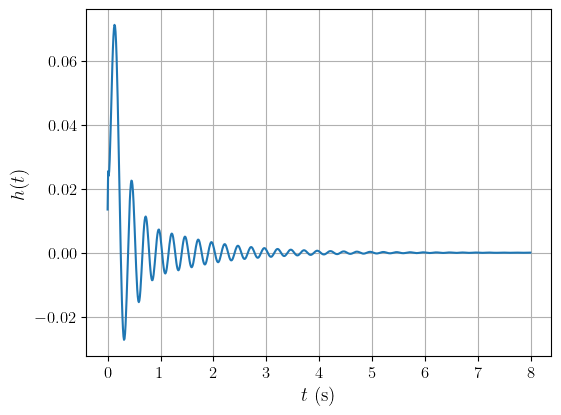

In [3]:
# Réponse impulsionnelle

d = np.concatenate([[1], np.zeros(N-1)])
z = signal.lfilter(b,a,d)

fig = plt.figure(figsize=figure_size)
plt.plot(t, z)
plt.xlabel("$t$ (s)", fontsize=14)
plt.ylabel("$h(t)$", fontsize=14)
fig.savefig("intro-repimp.svg", bbox_inches='tight')
fig.savefig("intro-repimp.png", bbox_inches='tight')
plt.show()

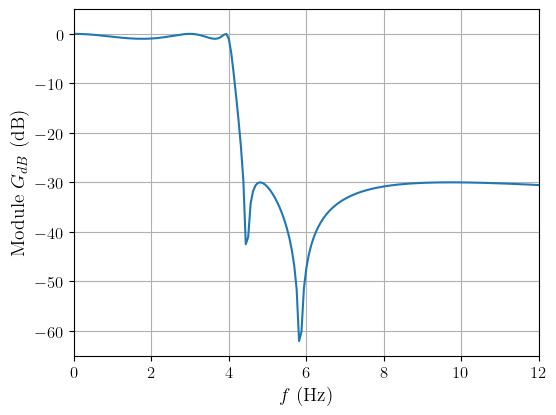

In [4]:
# Gain

fig = plt.figure(figsize=figure_size)
plt.plot(w, 20*np.log10(abs(h)))
plt.xlim(xlim)
plt.ylim([-65, 5])
plt.xlabel("$f$ (Hz)", fontsize=14)
plt.ylabel("Module $G_{dB}$ (dB)", fontsize=14)
fig.savefig("intro-gain.svg", bbox_inches='tight')
fig.savefig("intro-gain.png", bbox_inches='tight')
plt.show()

<>:9: SyntaxWarning: invalid escape sequence '\p'
<>:9: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_11167/3500794474.py:9: SyntaxWarning: invalid escape sequence '\p'
  plt.annotate('Ce saut de $2\pi$ permet à la\nphase de rester dans $[-\pi,\pi]$',


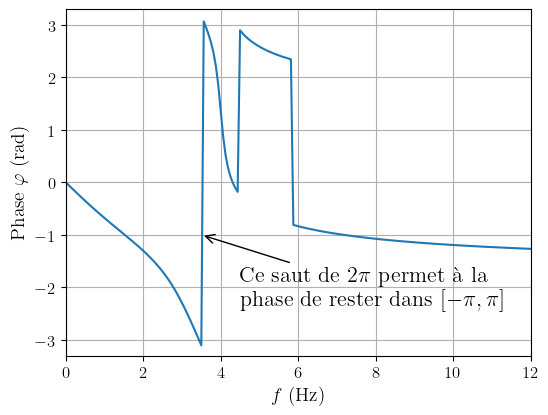

In [5]:
# Phase

fig = plt.figure(figsize=figure_size)
plt.plot(w, np.angle(h))
plt.xlim(xlim)
plt.ylim([-3.3, 3.3])
plt.xlabel("$f$ (Hz)", fontsize=14)
plt.ylabel("Phase $\\varphi$ (rad)", fontsize=14)
plt.annotate('Ce saut de $2\pi$ permet à la\nphase de rester dans $[-\pi,\pi]$',
             xy=(3.5, -1), xytext=(4.5, -2.35),
             arrowprops=dict(arrowstyle="->"),
            fontsize=16)
fig.savefig("intro-phase.svg", bbox_inches='tight')
fig.savefig("intro-phase.png", bbox_inches='tight')
plt.show()

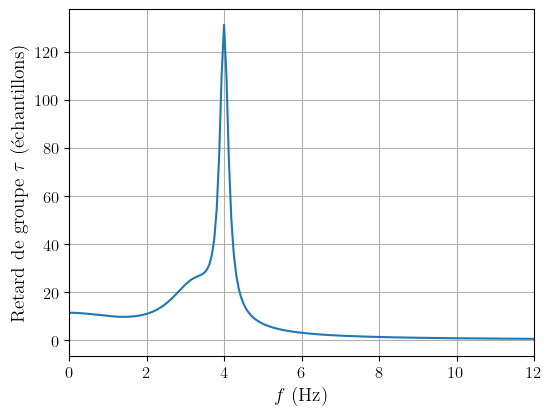

In [6]:
# Retard de groupe

fig = plt.figure(figsize=figure_size)
plt.plot(w, gd)
plt.xlim(xlim)
plt.xlabel("$f$ (Hz)", fontsize=14)
plt.ylabel("Retard de groupe $\\tau$ (échantillons)", fontsize=14)
fig.savefig("intro-retard-groupe.svg", bbox_inches='tight')
fig.savefig("intro-retard-groupe.png", bbox_inches='tight')
plt.show()

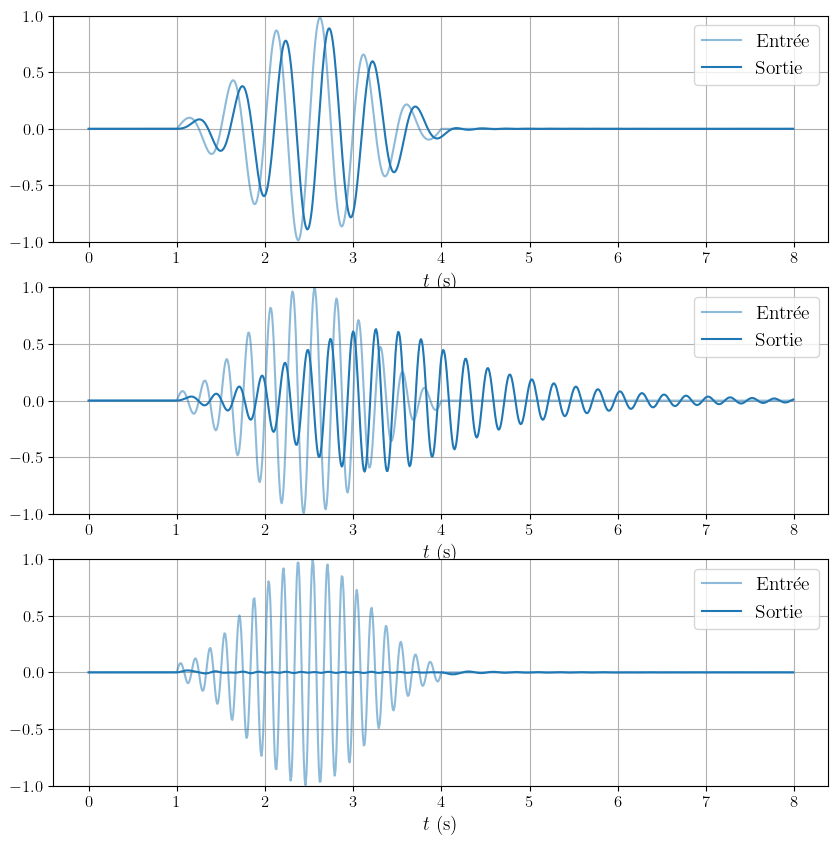

In [7]:
# Signaux d'entrée et de sortie

# Mise en évidence du retard de groupe
_, gdxx = signal.group_delay((b,a), w=np.array([f1, f2, f3]), whole=False, fs=fe)
to = 2

x = [x1, x2, x3]
y = [y1, y2, y3]
fig, axs = plt.subplots(3,1, figsize=(10,10))
for i in range(3):
    axs[i].plot(t, x[i], label='Entrée', color='C0', alpha=.5)
    axs[i].plot(t, y[i], label='Sortie', color='C0', alpha=1)
    # axs[i].axvline(to,color='k')
    # axs[i].axvline(to+gdxx[i]/fe,color='k')
    axs[i].set_ylim([-1, 1])
    axs[i].set_xlabel('$t$ (s)')
    axs[i].legend()
fig.savefig("intro-filtrage.svg", bbox_inches='tight')
fig.savefig("intro-filtrage.png", bbox_inches='tight')
plt.show()